# Lab 3: Intuición estadística
## Solución desarrollada con contexto matemático y análisis reproducible

Esta solución sigue la estructura del laboratorio: primero se fija el marco matemático, después se ejecuta la selección del modelo, luego se revisa la curva de aprendizaje y finalmente se construyen ejemplos sintéticos de sobreajuste y subajuste.

## Contexto matemático

En este laboratorio se estudia la elección de hiperparámetros para un clasificador no lineal con kernel RBF. La idea central es comparar el error empírico en entrenamiento, validación y prueba para evitar elegir un modelo que memorice el entrenamiento pero generalice mal.

Para un clasificador con kernel gaussiano, la función de similitud es

$\displaystyle K(x, x') = xp(-\gamma \|x - x'\|^2)$

donde $\gamma$ controla el alcance del kernel. Si $\gamma$ es muy pequeño, la frontera suele ser muy suave y el modelo puede subajustar. Si $\gamma$ es muy grande, la frontera se vuelve muy flexible y puede sobreajustar.

La estrategia de selección sigue tres pasos:
1. Ajustar el modelo en entrenamiento.
2. Elegir el mejor valor de $\gamma$ con validación o validación cruzada.
3. Evaluar el desempeño final en el conjunto de prueba, reservado desde el inicio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Modelo base y partición de datos

Para ilustrar la selección del parámetro $\gamma$ usamos un conjunto no lineal con dos clases. El particionado sigue la regla pedida en el laboratorio: 20% para prueba y 80% para entrenamiento/validación. Dentro de ese 80%, se reserva 10% del total para validación y 70% para entrenamiento.

Entrenamiento: 350 muestras
Validación:     50 muestras
Prueba:         100 muestras


,gamma,train_accuracy,val_accuracy
0,0.001000,0.840000,0.84
1,0.002276,0.842857,0.86
2,0.005179,0.842857,0.86
3,0.011788,0.842857,0.88
4,0.026827,0.851429,0.86
5,0.061054,0.854286,0.86
6,0.138950,0.911429,0.90
7,0.316228,0.934286,0.98
8,0.719686,0.940000,0.96
9,1.637894,0.948571,0.92


Mejor gamma por validación manual: 0.316228
Accuracy de validación: 0.9800


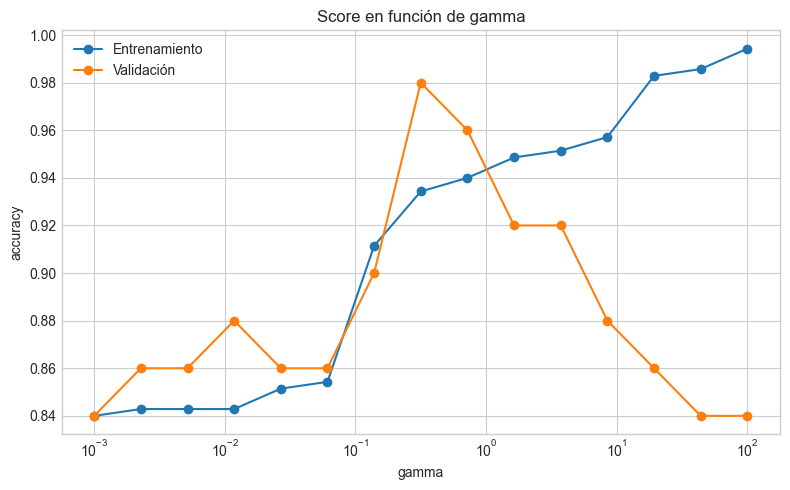

In [2]:
# Dataset no lineal de referencia
X, y = make_moons(n_samples=500, noise=0.28, random_state=42)

# 20% test y 80% para train + validación
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Dentro del 80% restante: 70% train y 10% validación del total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, stratify=y_train_val, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Validación:     {X_val.shape[0]} muestras')
print(f'Prueba:         {X_test.shape[0]} muestras')

# Curvas de referencia para distintos valores de gamma
gamma_grid = np.logspace(-3, 2, 15)
train_scores = []
val_scores = []

for gamma in gamma_grid:
    model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0, gamma=gamma))
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    val_scores.append(model.score(X_val, y_val))

results_gamma = pd.DataFrame({
    'gamma': gamma_grid,
    'train_accuracy': train_scores,
    'val_accuracy': val_scores
})
best_manual_row = results_gamma.loc[results_gamma['val_accuracy'].idxmax()]
best_manual_gamma = float(best_manual_row['gamma'])

display(results_gamma)
print(f"Mejor gamma por validación manual: {best_manual_gamma:.6f}")
print(f"Accuracy de validación: {best_manual_row['val_accuracy']:.4f}")

plt.figure(figsize=(8, 5))
plt.semilogx(gamma_grid, train_scores, marker='o', label='Entrenamiento')
plt.semilogx(gamma_grid, val_scores, marker='o', label='Validación')
plt.xlabel('gamma')
plt.ylabel('accuracy')
plt.title('Score en función de gamma')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Selección de hiperparámetro con GridSearchCV

La validación manual anterior usa una sola partición. Para comprobar que la tendencia no depende de una sola división, se ajusta un GridSearchCV con validación cruzada interna. Esto permite comparar el mejor valor de $\gamma$ y luego medir el desempeño en el conjunto de prueba reservado.

In [3]:
pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0))
param_grid = {'svc__gamma': gamma_grid}
grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_val, y_train_val)

print(f"Mejor gamma por GridSearchCV: {grid.best_params_['svc__gamma']:.6f}")
print(f"Mejor score medio en CV: {grid.best_score_:.4f}")

best_grid_model = grid.best_estimator_
test_accuracy = best_grid_model.score(X_test, y_test)
print(f"Accuracy final en prueba: {test_accuracy:.4f}")

comparison = pd.DataFrame({
    'source': ['manual validation', 'GridSearchCV'],
    'best_gamma': [best_manual_gamma, grid.best_params_['svc__gamma']]
})
display(comparison)

Mejor gamma por GridSearchCV: 3.727594
Mejor score medio en CV: 0.9400
Accuracy final en prueba: 0.9200


,source,best_gamma
0,manual validation,0.316228
1,GridSearchCV,3.727594


## 3. Curvas de aprendizaje

Las curvas de aprendizaje muestran cómo cambia el rendimiento al aumentar el tamaño de entrenamiento. Si las curvas de entrenamiento y validación están muy separadas, hay alta varianza; si ambas están bajas y cercanas, hay alto sesgo.

,train_size,train_accuracy_mean,val_accuracy_mean
0,64,0.987500,0.8600
1,115,0.972174,0.8825
2,166,0.959036,0.8875
3,217,0.953917,0.9200
4,268,0.955224,0.9300
5,320,0.953750,0.9400


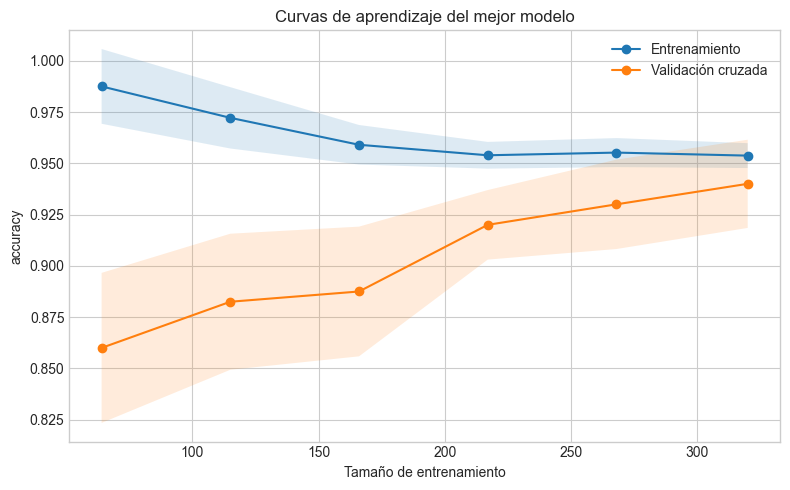

In [4]:
best_learning_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0, gamma=grid.best_params_['svc__gamma']))
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    best_learning_model,
    X_train_val,
    y_train_val,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores_lc.mean(axis=1)
train_std = train_scores_lc.std(axis=1)
val_mean = val_scores_lc.mean(axis=1)
val_std = val_scores_lc.std(axis=1)

lc_df = pd.DataFrame({
    'train_size': train_sizes,
    'train_accuracy_mean': train_mean,
    'val_accuracy_mean': val_mean
})
display(lc_df)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Entrenamiento')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, marker='o', label='Validación cruzada')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.xlabel('Tamaño de entrenamiento')
plt.ylabel('accuracy')
plt.title('Curvas de aprendizaje del mejor modelo')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Ejemplos de sobreajuste y subajuste

Para ilustrar el comportamiento del modelo en datos nuevos, se generan dos problemas gaussianos en dos dimensiones. En el primer caso las clases están muy solapadas y el mejor clasificador tiende a subajustar. En el segundo caso se usan pocas observaciones con ruido puntual, lo que favorece una frontera demasiado flexible y, por tanto, sobreajuste.

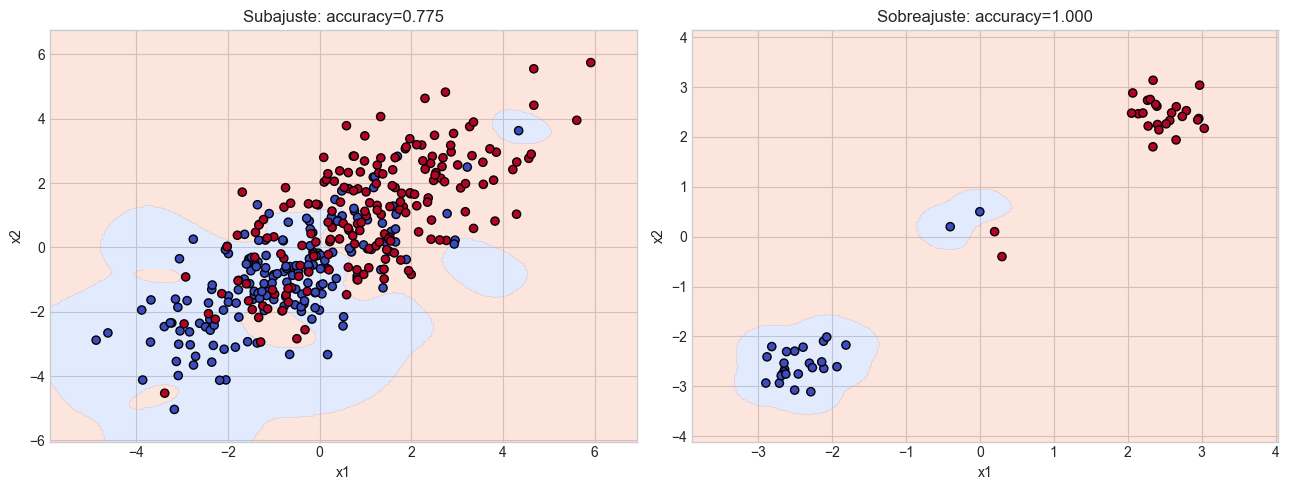

Accuracy en el problema subajustado: 0.7750
Accuracy en el problema sobreajustado sobre entrenamiento: 1.0000


In [5]:
def sample_gaussian_class(mean, cov, n, label, rng):
    samples = rng.multivariate_normal(mean, cov, size=n)
    labels = np.full(n, label)
    return samples, labels

def plot_decision_boundary(ax, model, X_data, y_data, title):
    x_min, x_max = X_data[:, 0].min() - 1.0, X_data[:, 0].max() + 1.0
    y_min, y_max = X_data[:, 1].min() - 1.0, X_data[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid_points).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, levels=np.arange(-0.5, 2, 1), cmap='coolwarm')
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap='coolwarm', edgecolor='k', s=35)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

# Subajuste: solapamiento fuerte
under_mean_0 = np.array([-1.0, -1.0])
under_mean_1 = np.array([1.0, 1.0])
under_cov = np.array([[2.8, 1.9], [1.9, 2.8]])
X0_u, y0_u = sample_gaussian_class(under_mean_0, under_cov, 180, 0, np.random.default_rng(7))
X1_u, y1_u = sample_gaussian_class(under_mean_1, under_cov, 180, 1, np.random.default_rng(8))
X_under = np.vstack([X0_u, X1_u])
y_under = np.concatenate([y0_u, y1_u])

under_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0, gamma=grid.best_params_['svc__gamma']))
under_model.fit(X_under, y_under)
under_acc = under_model.score(X_under, y_under)

# Sobreajuste: pocas muestras, covarianza pequeña y algunos puntos atípicos
over_mean_0 = np.array([-2.5, -2.5])
over_mean_1 = np.array([2.5, 2.5])
over_cov = np.array([[0.12, 0.02], [0.02, 0.12]])
X0_o, y0_o = sample_gaussian_class(over_mean_0, over_cov, 24, 0, np.random.default_rng(11))
X1_o, y1_o = sample_gaussian_class(over_mean_1, over_cov, 24, 1, np.random.default_rng(12))
outliers = np.array([[0.0, 0.5], [0.3, -0.4], [-0.4, 0.2], [0.2, 0.1]])
outlier_labels = np.array([0, 1, 0, 1])
X_over = np.vstack([X0_o, X1_o, outliers])
y_over = np.concatenate([y0_o, y1_o, outlier_labels])

over_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10.0, gamma=max(gamma_grid)))
over_model.fit(X_over, y_over)
over_acc = over_model.score(X_over, y_over)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_decision_boundary(axes[0], under_model, X_under, y_under, f'Subajuste: accuracy={under_acc:.3f}')
plot_decision_boundary(axes[1], over_model, X_over, y_over, f'Sobreajuste: accuracy={over_acc:.3f}')
plt.tight_layout()
plt.show()

print(f'Accuracy en el problema subajustado: {under_acc:.4f}')
print(f'Accuracy en el problema sobreajustado sobre entrenamiento: {over_acc:.4f}')

## Conclusiones

1. El parámetro $\gamma$ controla la flexibilidad del kernel RBF. En este laboratorio se ve que valores intermedios suelen equilibrar mejor entrenamiento y validación que valores extremos.
2. GridSearchCV confirma la tendencia observada manualmente y permite elegir el hiperparámetro sin depender de una sola partición.
3. Las curvas de aprendizaje ayudan a diagnosticar si el modelo necesita más datos o si el problema está dominado por sesgo.
4. En los experimentos sintéticos, el subajuste aparece cuando las clases se solapan demasiado y la frontera no puede separar bien la estructura, mientras que el sobreajuste aparece cuando el modelo flexible intenta seguir detalles espurios o puntos atípicos.

La solución queda organizada para que cada bloque tenga una intención clara: contexto matemático, selección de modelo, validación, aprendizaje y análisis de comportamiento extremo.